Categorieën gebruikt:
categoryTitle
Groente, aardappelen                 242
Vlees                                148
Maaltijden, salades                  145
Zuivel, eieren                       114
Bakkerij                             107
Vegetarisch, vegan en plantaardig     79
Fruit, verse sappen                   51
Name: count, dtype: int64


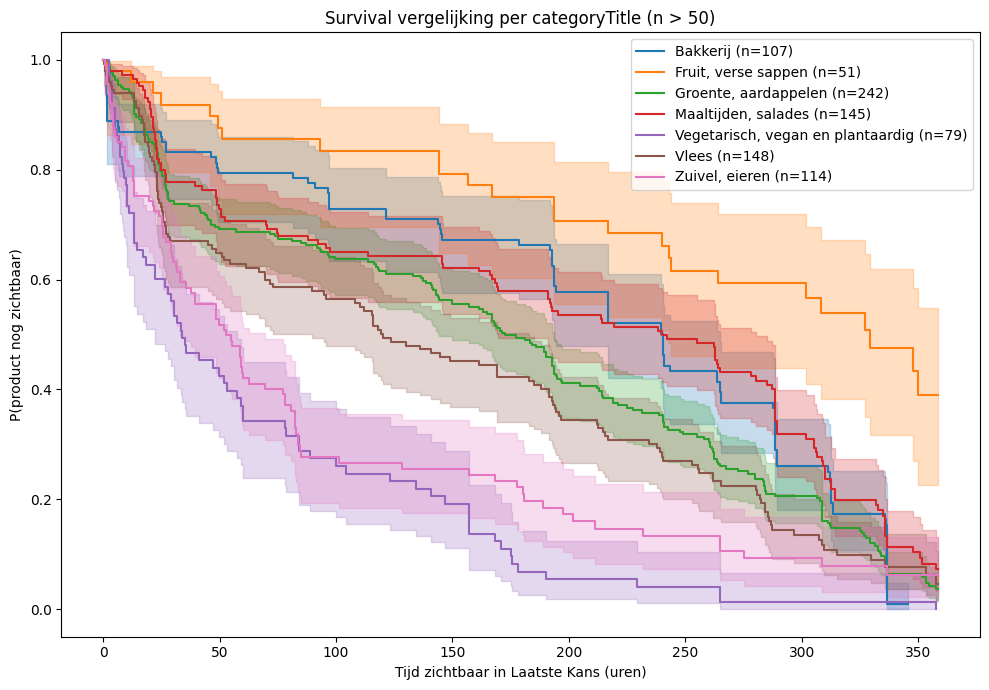

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# ===== 1. Opschonen =====
df = df.copy()

df["fetch_timestamp"] = pd.to_datetime(df["fetch_timestamp"], errors="coerce")
df = df.dropna(subset=["fetch_timestamp", "title", "categoryTitle"])
df = df.sort_values("fetch_timestamp")

# uniek product
df["product_key"] = (
    df["title"].astype(str).str.strip()
    + " | " +
    df["brand"].astype(str).str.strip()
)

# ===== 2. Survival table =====
dataset_end = df["fetch_timestamp"].max()

lifetimes = (
    df.groupby(["categoryTitle", "product_key"], as_index=False)
      .agg(
          start=("fetch_timestamp", "min"),
          end=("fetch_timestamp", "max")
      )
)

lifetimes["duration_hours"] = (
    lifetimes["end"] - lifetimes["start"]
).dt.total_seconds() / 3600

lifetimes = lifetimes[lifetimes["duration_hours"] > 0]

# censored items
lifetimes["event"] = (lifetimes["end"] < dataset_end).astype(int)

# ===== 3. Filter categorieën met n > 50 =====
counts = lifetimes["categoryTitle"].value_counts()
valid_categories = counts[counts > 50].index

lifetimes_filtered = lifetimes[
    lifetimes["categoryTitle"].isin(valid_categories)
]

print("Categorieën gebruikt:")
print(counts[counts > 50])

# ===== 4. Plot alles in één vergelijking =====
kmf = KaplanMeierFitter()

plt.figure(figsize=(10,7))

for cat in sorted(valid_categories):
    subset = lifetimes_filtered[
        lifetimes_filtered["categoryTitle"] == cat
    ]

    kmf.fit(
        subset["duration_hours"],
        subset["event"],
        label=f"{cat} (n={len(subset)})"
    )

    kmf.plot_survival_function()

plt.title("Survival vergelijking per categoryTitle (n > 50)")
plt.xlabel("Tijd zichtbaar in Laatste Kans (uren)")
plt.ylabel("P(product nog zichtbaar)")
plt.legend()
plt.tight_layout()
plt.show()


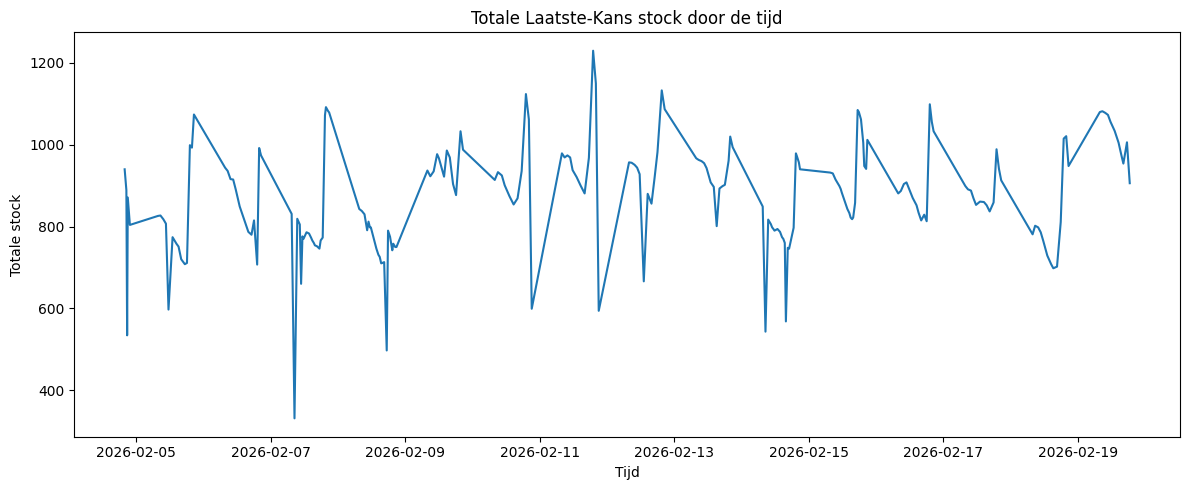

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = df.copy()
df["fetch_timestamp"] = pd.to_datetime(df["fetch_timestamp"])

# totale stock per meetmoment
stock_ts = (
    df.groupby("fetch_timestamp")["stock"]
      .sum()
      .reset_index()
      .sort_values("fetch_timestamp")
)

# plot
plt.figure(figsize=(12,5))
plt.plot(stock_ts["fetch_timestamp"], stock_ts["stock"])

plt.title("Totale Laatste-Kans stock door de tijd")
plt.xlabel("Tijd")
plt.ylabel("Totale stock")
plt.tight_layout()
plt.show()


Mean arrivals: 1.324022346368715
Variance: 22.658499042856587
Dispersion (var/mean): 17.1133811336343


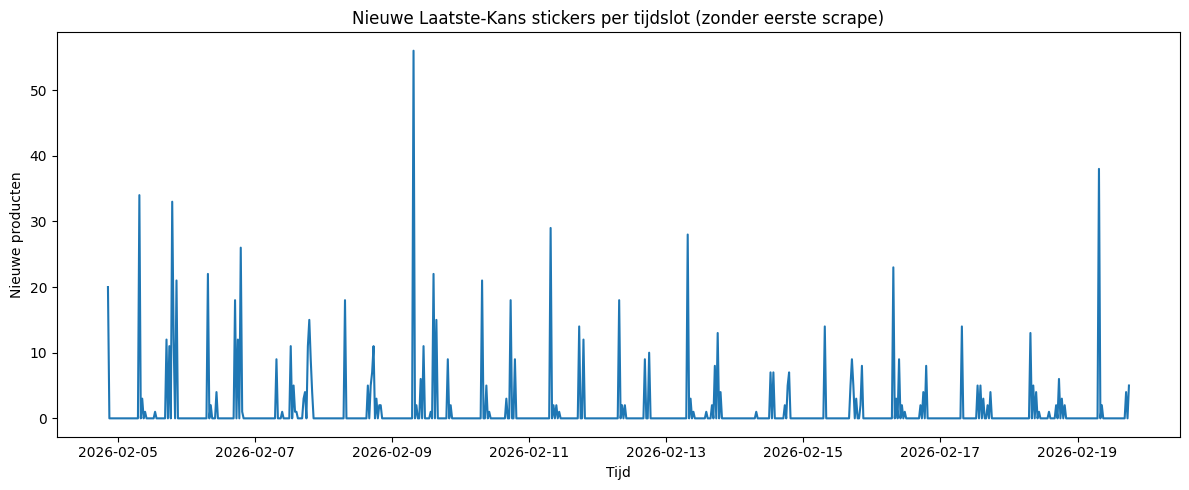

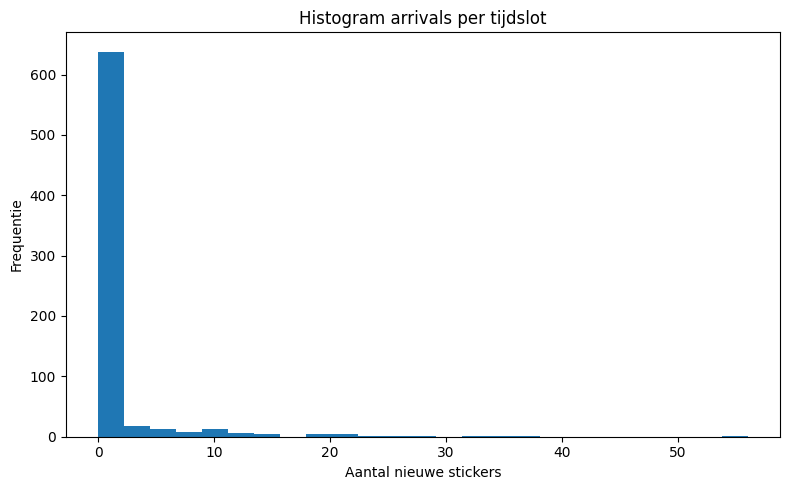


Top sticker momenten:
               time_bin  new_items
214 2026-02-09 07:30:00         56
694 2026-02-19 07:30:00         38
22  2026-02-05 07:30:00         34
45  2026-02-05 19:00:00         33
310 2026-02-11 07:30:00         29
406 2026-02-13 07:30:00         28
93  2026-02-06 19:00:00         26
550 2026-02-16 07:30:00         23
70  2026-02-06 07:30:00         22
228 2026-02-09 14:30:00         22
262 2026-02-10 07:30:00         21
48  2026-02-05 20:30:00         21
0   2026-02-04 20:30:00         20
358 2026-02-12 07:30:00         18
282 2026-02-10 17:30:00         18


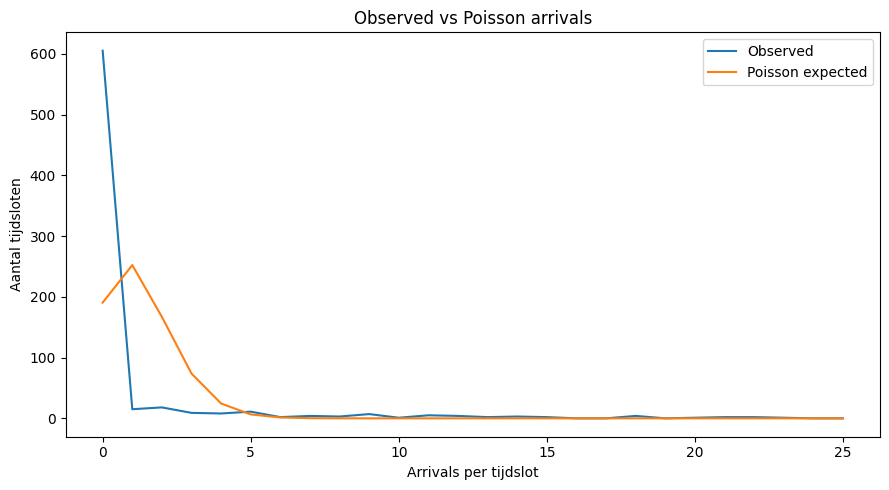

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import exp, factorial

# =========================
# Poisson arrival analysis
# =========================

df = df.copy()

# ---- 1) Clean timestamps ----
df["fetch_timestamp"] = pd.to_datetime(df["fetch_timestamp"], errors="coerce")
df = df.dropna(subset=["fetch_timestamp", "title", "brand"])
df = df.sort_values("fetch_timestamp")

# ---- 2) Product key ----
df["product_key"] = (
    df["title"].astype(str).str.strip()
    + " | "
    + df["brand"].astype(str).str.strip()
)

# ---- 3) First appearance per product ----
first_seen = (
    df.groupby("product_key", as_index=False)["fetch_timestamp"]
      .min()
      .rename(columns={"fetch_timestamp": "first_seen"})
)

# ---- 4) REMOVE FIRST SCRAPE ARTIFACT ----
first_timestamp = df["fetch_timestamp"].min()

# keep only products that appeared AFTER first log
first_seen = first_seen[first_seen["first_seen"] > first_timestamp]

# ---- 5) Bin arrivals ----
BIN = "30min"

first_seen["time_bin"] = first_seen["first_seen"].dt.floor(BIN)

arrivals = (
    first_seen.groupby("time_bin")
      .size()
      .rename("new_items")
      .sort_index()
)

# complete timeline (fill gaps with 0)
full_index = pd.date_range(arrivals.index.min(), arrivals.index.max(), freq=BIN)
arrivals = arrivals.reindex(full_index, fill_value=0)
arrivals.index.name = "time_bin"
arrivals = arrivals.reset_index()

# ---- 6) Mean vs variance (Poisson check) ----
mu = arrivals["new_items"].mean()
var = arrivals["new_items"].var(ddof=1)

print("Mean arrivals:", mu)
print("Variance:", var)
print("Dispersion (var/mean):", var / mu if mu > 0 else np.nan)

# ---- 7) Time series plot ----
plt.figure(figsize=(12,5))
plt.plot(arrivals["time_bin"], arrivals["new_items"])
plt.title("Nieuwe Laatste-Kans stickers per tijdslot (zonder eerste scrape)")
plt.xlabel("Tijd")
plt.ylabel("Nieuwe producten")
plt.tight_layout()
plt.show()

# ---- 8) Histogram ----
plt.figure(figsize=(8,5))
plt.hist(arrivals["new_items"], bins=25)
plt.title("Histogram arrivals per tijdslot")
plt.xlabel("Aantal nieuwe stickers")
plt.ylabel("Frequentie")
plt.tight_layout()
plt.show()

# ---- 9) Largest sticker moments ----
print("\nTop sticker momenten:")
print(
    arrivals.sort_values("new_items", ascending=False)
            .head(15)[["time_bin", "new_items"]]
)

# ---- 10) Observed vs Poisson comparison ----
max_k = int(min(arrivals["new_items"].max(), 25))
obs = arrivals["new_items"].value_counts().reindex(range(max_k+1), fill_value=0).sort_index()

def poisson_pmf(k, lam):
    return (lam**k) * exp(-lam) / factorial(k) if lam > 0 else 0

expected = np.array([poisson_pmf(k, mu) for k in range(max_k+1)]) * len(arrivals)

plt.figure(figsize=(9,5))
plt.plot(obs.index, obs.values, label="Observed")
plt.plot(range(max_k+1), expected, label="Poisson expected")
plt.title("Observed vs Poisson arrivals")
plt.xlabel("Arrivals per tijdslot")
plt.ylabel("Aantal tijdsloten")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.stats import chi2

x = arrivals["new_items"].to_numpy()
n = len(x)
mu = x.mean()
s2 = x.var(ddof=1)

D = s2 / mu
chi_stat = (n - 1) * D
p_value = 1 - chi2.cdf(chi_stat, df=n-1)

print("n:", n)
print("mean:", mu)
print("var:", s2)
print("dispersion D=var/mean:", D)
print("chi_stat:", chi_stat)
print("p-value (overdispersion vs Poisson):", p_value)


n: 716
mean: 1.324022346368715
var: 22.658499042856587
dispersion D=var/mean: 17.1133811336343
chi_stat: 12236.067510548524
p-value (overdispersion vs Poisson): 0.0


In [ ]:
import numpy as np
from scipy.stats import binomtest

x = arrivals["new_items"].to_numpy()
n = len(x)
mu = x.mean()

p0_poisson = np.exp(-mu)
k0 = np.sum(x == 0)

res = binomtest(k0, n, p0_poisson, alternative="greater")
print("Observed zero fraction:", k0/n)
print("Poisson expected zero fraction:", p0_poisson)
print("p-value (more zeros than Poisson):", res.pvalue)


Observed zero fraction: 0.8449720670391061
Poisson expected zero fraction: 0.26606294938660713
p-value (more zeros than Poisson): 9.394440689020898e-231


In [ ]:
import pandas as pd
import numpy as np

df = df.copy()
df["fetch_timestamp"] = pd.to_datetime(df["fetch_timestamp"], errors="coerce")
df = df.dropna(subset=["fetch_timestamp", "title", "brand"]).sort_values("fetch_timestamp")

df["product_key"] = df["title"].astype(str).str.strip() + " | " + df["brand"].astype(str).str.strip()

first_seen = (
    df.groupby("product_key", as_index=False)["fetch_timestamp"]
      .min()
      .rename(columns={"fetch_timestamp": "first_seen"})
)

BIN = "30min"
BURN_IN_HOURS = 12

start_time = df["fetch_timestamp"].min()
cutoff_time = start_time + pd.Timedelta(hours=BURN_IN_HOURS)
first_seen = first_seen[first_seen["first_seen"] > cutoff_time].copy()

first_seen["time_bin"] = first_seen["first_seen"].dt.floor(BIN)

arrivals = (
    first_seen.groupby("time_bin")
      .size()
      .rename("new_items")
      .sort_index()
)

full_index = pd.date_range(arrivals.index.min(), arrivals.index.max(), freq=BIN)
arrivals = arrivals.reindex(full_index, fill_value=0).to_frame().reset_index().rename(columns={"index":"time_bin"})


In [ ]:
# Kies drempel: top 5% van bins als "actief"
q = 0.95
threshold = arrivals["new_items"].quantile(q)

arrivals["is_peak"] = arrivals["new_items"] >= threshold

# Cluster opeenvolgende peak-bins tot één ronde
arrivals = arrivals.sort_values("time_bin").reset_index(drop=True)
arrivals["peak_block"] = (arrivals["is_peak"] != arrivals["is_peak"].shift(1)).cumsum()

peak_blocks = arrivals[arrivals["is_peak"]].groupby("peak_block").agg(
    start=("time_bin", "min"),
    end=("time_bin", "max"),
    total_new=("new_items", "sum"),
    max_new=("new_items", "max"),
    bins=("new_items", "size")
).reset_index(drop=True)

peak_blocks["duration_minutes"] = ((peak_blocks["end"] - peak_blocks["start"]).dt.total_seconds() / 60) + 30
peak_blocks["midpoint"] = peak_blocks["start"] + (peak_blocks["end"] - peak_blocks["start"]) / 2

print("Aantal rondes gevonden:", len(peak_blocks))
print(peak_blocks.sort_values("total_new", ascending=False).head(15))


Aantal rondes gevonden: 36
                 start                 end  total_new  max_new  bins  \
13 2026-02-09 07:30:00 2026-02-09 07:30:00         56       56     1   
2  2026-02-05 19:00:00 2026-02-05 19:30:00         45       33     2   
35 2026-02-19 07:30:00 2026-02-19 07:30:00         38       38     1   
10 2026-02-07 18:30:00 2026-02-07 19:30:00         35       15     3   
21 2026-02-11 07:30:00 2026-02-11 07:30:00         29       29     1   
27 2026-02-13 07:30:00 2026-02-13 07:30:00         28       28     1   
7  2026-02-06 19:00:00 2026-02-06 19:00:00         26       26     1   
31 2026-02-16 07:30:00 2026-02-16 07:30:00         23       23     1   
15 2026-02-09 14:30:00 2026-02-09 14:30:00         22       22     1   
4  2026-02-06 07:30:00 2026-02-06 07:30:00         22       22     1   
3  2026-02-05 20:30:00 2026-02-05 20:30:00         21       21     1   
18 2026-02-10 07:30:00 2026-02-10 07:30:00         21       21     1   
19 2026-02-10 17:30:00 2026-02-10 17:

In [ ]:
peak_blocks["hour"] = peak_blocks["midpoint"].dt.hour
by_hour = peak_blocks.groupby("hour").size().rename("rounds").reset_index()

print(by_hour.sort_values("rounds", ascending=False).head(10))


   hour  rounds
0     7      13
7    17       6
9    19       6
8    18       4
1     9       1
2    11       1
3    12       1
6    16       1
5    15       1
4    14       1


In [ ]:
top_hours = by_hour.sort_values("rounds", ascending=False).head(5)
print("Meest voorkomende ronde uren:")
print(top_hours.to_string(index=False))


Meest voorkomende ronde uren:
 hour  rounds
    7      13
   17       6
   19       6
   18       4
    9       1


In [ ]:
peak_blocks = peak_blocks.sort_values("midpoint").reset_index(drop=True)

peak_blocks["gap_hours"] = peak_blocks["midpoint"].diff().dt.total_seconds() / 3600

gaps = peak_blocks["gap_hours"].dropna()

print("Intervallen tussen rondes (uren)")
print("median:", gaps.median())
print("mean:", gaps.mean())
print("p25:", gaps.quantile(0.25))
print("p75:", gaps.quantile(0.75))


Intervallen tussen rondes (uren)
median: 9.5
mean: 9.32857142857143
p25: 1.75
p75: 12.5


In [ ]:
gap_bins = pd.cut(gaps, bins=[0,1,2,3,4,6,8,12,24,48], right=True)
print(gap_bins.value_counts().sort_index())


gap_hours
(0, 1]       4
(1, 2]       6
(2, 3]       0
(3, 4]       3
(4, 6]       1
(6, 8]       1
(8, 12]      9
(12, 24]    10
(24, 48]     1
Name: count, dtype: int64
